In [1]:
#chargement de la bibliothèque rootSolve
library(rootSolve)

In [2]:
# variables du problème
n = 150
x = 6
pa = 0.05
qa = 0.01
pb = 0.9
qb = 0.05


In [3]:
# Phase d'élicititation du prior

model = function(x, pa, qa, pb, qb){
  c(F1= pa - pbeta(qa, x[1], x[2]), F2= pb - pbeta(qb, x[1], x[2]))
}


In [16]:
sol=multiroot(f=model, start=c(1,10),maxiter=100,  positive = T, pa=pa, qa=qa, pb=pb, qb=qb)
p=sol$root[1]
q=sol$root[2]

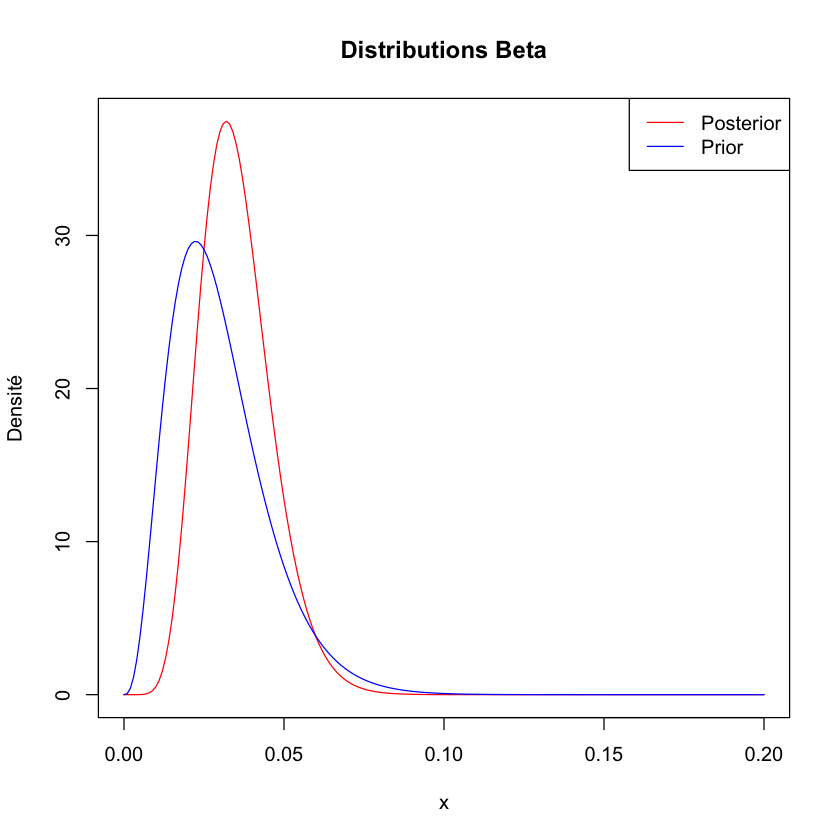

In [ ]:
# Créer un vecteur x pour couvrir toute la plage nécessaire
axe_x1 = seq(0, 0.2, 0.001)

# Ajouter le posterior
plot(axe_x1, dbeta(axe_x1, p+x, q+n-x), type="l", col="red", 
     xlab="x", ylab="Densité", main="Distributions Beta")
# Tracer le prior
lines(axe_x1, dbeta(axe_x1, p, q), type="l", col="blue")

# Ajouter une légende
legend("topright", legend=c("Posterior", "Prior"), 
       col=c("red", "blue"), lty=1)

In [34]:
polya = function(y, h, p, q, n, x){
  choose(h, y) * beta(y+x+p, h-y+n-x+q) / beta(x+p, n-x+q)
}


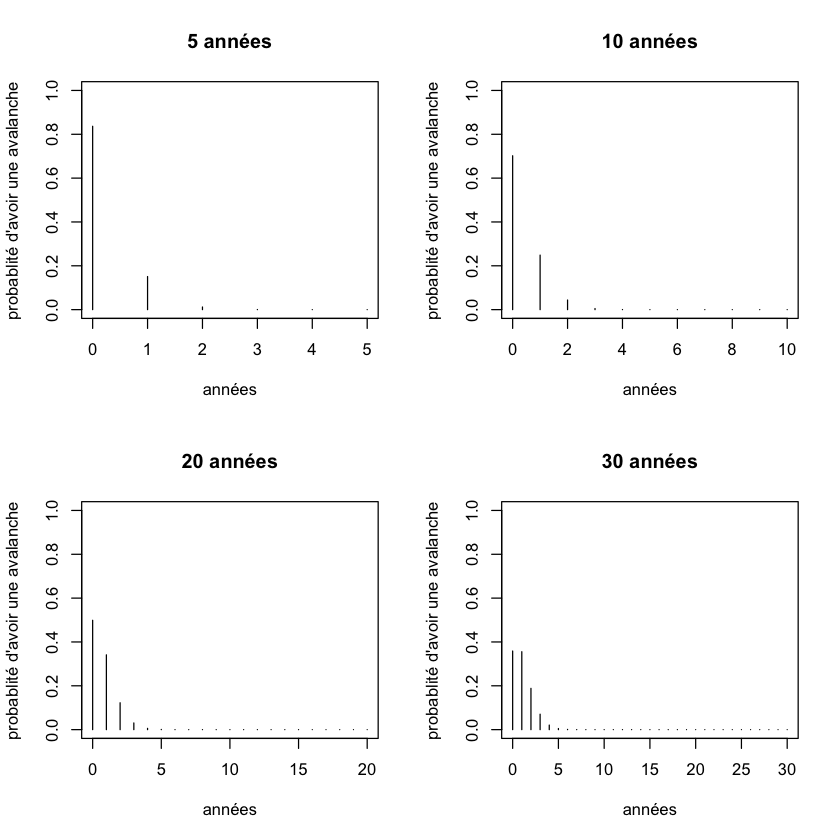

In [44]:
# Créer une mise en page 2x2 pour les graphiques
par(mfrow=c(2,2))

# Pour 5 années
y5=0:5
plot(y5, polya(y5, h=5, p,q,n,x), type="h", xlab="années", ylab="probablité d'avoir une avalanche", main="5 années", ylim=c(0,1))

# Pour 10 années 
y10=0:10
plot(y10, polya(y10, h=10, p,q,n,x), type="h", xlab="années", ylab="probablité d'avoir une avalanche", main="10 années", ylim=c(0,1))

# Pour 20 années
y20=0:20 
plot(y20, polya(y20, h=20, p,q,n,x), type="h", xlab="années", ylab="probablité d'avoir une avalanche", main="20 années", ylim=c(0,1))

# Pour 30 années
y30=0:30
plot(y30, polya(y30, h=30, p,q,n,x), type="h", xlab="années", ylab="probablité d'avoir une avalanche", main="30 années", ylim=c(0,1))

# Remettre la mise en page par défaut
par(mfrow=c(1,1))
